# Experiment No. 6

## PCA for Dimensionality Reduction on UCI Wine Dataset

### Aim
To compare the performance of Principal Component Analysis (PCA) as a dimensionality reduction technique on the UCI Wine dataset and evaluate its impact on classification accuracy and data visualization.

## Theory

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original features into a smaller number of uncorrelated principal components.

The first principal component captures the maximum variance in the data, the second captures the next highest variance, and so on.

In this experiment, PCA is used to reduce the original feature space to **2 principal components (PC1 and PC2)**.

These two components are then used as input to a Random Forest classifier and for 2D visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("wine.csv")

print(df.head())

   Class  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0      1    14.23        1.71  2.43               15.6        127   
1      1    13.20        1.78  2.14               11.2        100   
2      1    13.16        2.36  2.67               18.6        101   
3      1    14.37        1.95  2.50               16.8        113   
4      1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04                          3.92     1065  
1             4.38  1.05  

Check Dataset Information

In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Shape of dataset: (178, 14)

Column names:
Index(['Class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash',
       'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids               

Check Missing Values

In [4]:
print("Missing Values in each column:")
print(df.isnull().sum())

Missing Values in each column:
Class                           0
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64


In [5]:
print(df.columns.tolist())

['Class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']


Separate Features and Target

In [6]:
x = df.drop("Class", axis=1)

In [7]:
y = df["Class"]

Check X and Y

In [8]:
print("Feature Shape:", x.shape)
print("Target Shape:", y.shape)

print("\nFeatures:")
print(x.columns)

print("\nTarget Classes:")
print(y.unique())

Feature Shape: (178, 13)
Target Shape: (178,)

Features:
Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
       'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

Target Classes:
[1 2 3]


Train Test Split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (142, 13)
Testing data: (36, 13)


Standardize the Data

In [10]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Training data after standardization:")
print(x_train_scaled[:5])

Training data after standardization:
[[ 0.38580089 -0.63787118  1.77666817 -1.22453161  0.69643032  0.52686525
   0.73229212 -0.1695489  -0.41578344 -0.16746725  0.62437819  0.2529082
   0.46772474]
 [ 0.94851892 -0.76544542  1.25317383  0.85328406  0.09178497  1.17279546
   1.33318146 -0.59045701  1.34974202  0.30530313  1.06715537  0.15104809
   1.81576773]
 [ 0.52335419 -0.51940939  0.9540342  -1.04643312 -0.44567755  0.93057163
   1.006382   -0.1695489  -0.26000178 -0.081509   -0.12834302  0.89317174
   1.51620262]
 [ 0.97352861 -0.55585917  0.16879269 -1.0761162  -0.71440882  0.52686525
   0.81662747 -0.59045701  0.36312485  0.262324    0.8900445   0.42752553
   1.93226527]
 [ 0.43582027  0.82012009  0.05661533  0.55645325 -0.51286037 -0.55506784
  -1.29175618  0.75644894 -0.60618325  1.47433535 -1.76661859 -1.43505932
  -0.29783054]]


Apply PCA

In [11]:
pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print("Original number of features:", x_train.shape[1])
print("Number of PCA components:", x_train_pca.shape[1])

Original number of features: 13
Number of PCA components: 2


Explained Variance

In [13]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.35792104 0.19270671]

Total variance explained by 2 components: 0.5506277578733126


Train Random Forest on PCA Data

In [14]:
rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_pca.fit(x_train_pca, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction Using PCA Data

In [15]:
y_pred_pca = rf_pca.predict(x_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)

print("Accuracy using PCA:", accuracy_pca)
print("Accuracy using PCA (%):", accuracy_pca*100)

Accuracy using PCA: 0.8888888888888888
Accuracy using PCA (%): 88.88888888888889


PCA Visualization

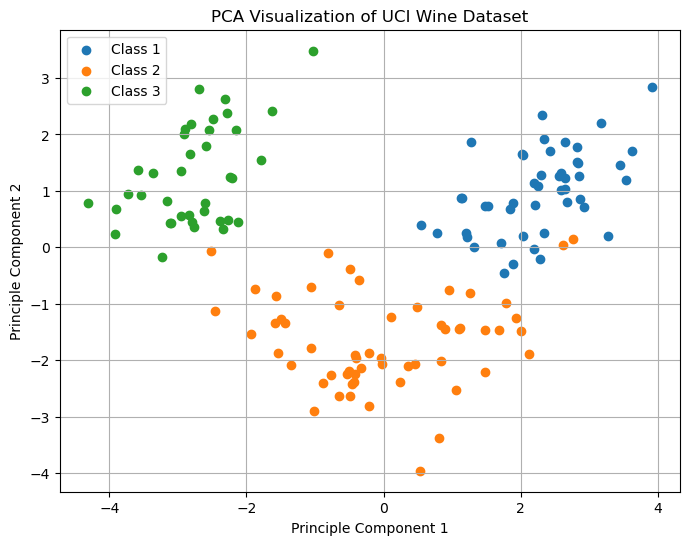

In [16]:
plt.figure(figsize=(8,6))

for class_label in np.unique(y_train):
    plt.scatter(
        x_train_pca[y_train.to_numpy() == class_label, 0],
        x_train_pca[y_train.to_numpy() == class_label, 1],
        label=f"Class {class_label}"
    )
    
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.title("PCA Visualization of UCI Wine Dataset")
plt.legend()
plt.grid(True)
plt.show()

Better Visualization Using Complete Dataset

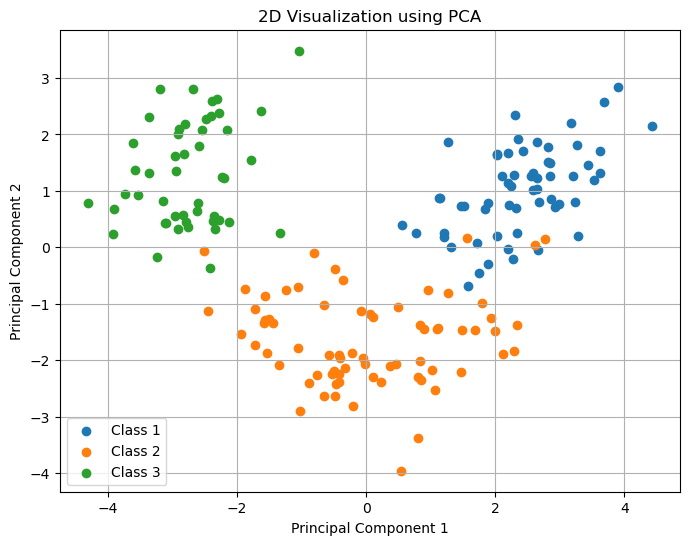

In [17]:
x_scaled = scaler.transform(x)
x_pca = pca.transform(x_scaled)

plt.figure(figsize=(8,6))

for class_label in np.unique(y):
    plt.scatter(
        x_pca[y.to_numpy() == class_label, 0],
        x_pca[y.to_numpy() == class_label, 1],
        label = f"Class {class_label}"
    )
    
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D Visualization using PCA")
plt.legend()
plt.grid(True)
plt.show()

Explained Variance Plot

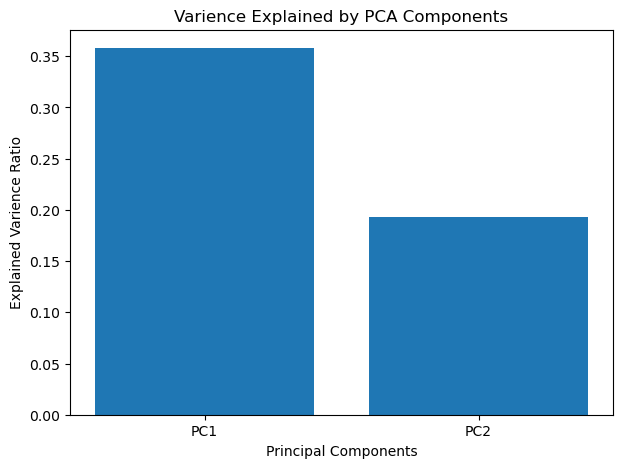

In [18]:
plt.figure(figsize=(7,5))

components = ["PC1", "PC2"]

plt.bar(
    components,
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Varience Ratio")
plt.title("Varience Explained by PCA Components")
plt.show()

## Result

PCA was successfully applied to the UCI Wine dataset to reduce the dimensionality of the feature space to two principal components.

A Random Forest classifier was trained using the PCA-transformed data and its classification accuracy was compared with the Random Forest classifier trained using the original standardized features.

The PCA-transformed data was also visualized using PC1 and PC2. The visualization shows the distribution and separation of different wine classes in the reduced two-dimensional space.

The method with the higher test accuracy is considered to have performed better for this experiment.